# Traffic Count Prediction
**Dataset:** 2,73,913 rows | 1,967 stations | 2006–2025  
**Goal:** Predict `traffic_count` for any station, year, period and vehicle type

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [2]:
# low_memory=False stops the mixed-type warning on date columns
df_org = pd.read_csv('Traffic_Data_Gov.csv', low_memory=False)
df = df_org.copy()
print('Shape :', df.shape)
print('Memory:', round(df.memory_usage(deep=True).sum() / 1_048_576, 1), 'MB')
df.head(3)

Shape : (273913, 27)
Memory: 206.1 MB


,the_geom,cartodb_id,the_geom_webmercator,record_id,station_key,station_id,traffic_direction_seq,traffic_direction_name,cardinal_direction_seq,cardinal_direction_name,...,traffic_count,data_start_date,data_end_date,data_duration,data_availability,data_reliability,data_quality_indicator,publish,md5,updated_on
0,NaN,670946,NaN,NaN,55318,02015,2,PRESCRIBED AND COUNTER,9,BOTH,...,39273,NaN,NaN,NaN,-1,-1,0,1,2c3a9b9bf222b4b98d5da5b20455e378,2018-12-14 05:33:24.64657+00
1,NaN,670947,NaN,NaN,15252005,6157,0,COUNTER,5,SOUTH,...,705,NaN,NaN,NaN,1,92,0,1,80c733285025af031a4fffaa89f004db,2022-02-04 09:44:28.431958+00
2,NaN,670948,NaN,NaN,57462,83011,0,COUNTER,5,SOUTH,...,1722,NaN,NaN,NaN,10,77,0,1,f93f7c9eb82be6744ae1fd7b2716ef55,2020-09-03 01:24:31.45111+00


## 2. Missing Values

Columns WITH missing  : 8
Columns with NO missing: 19


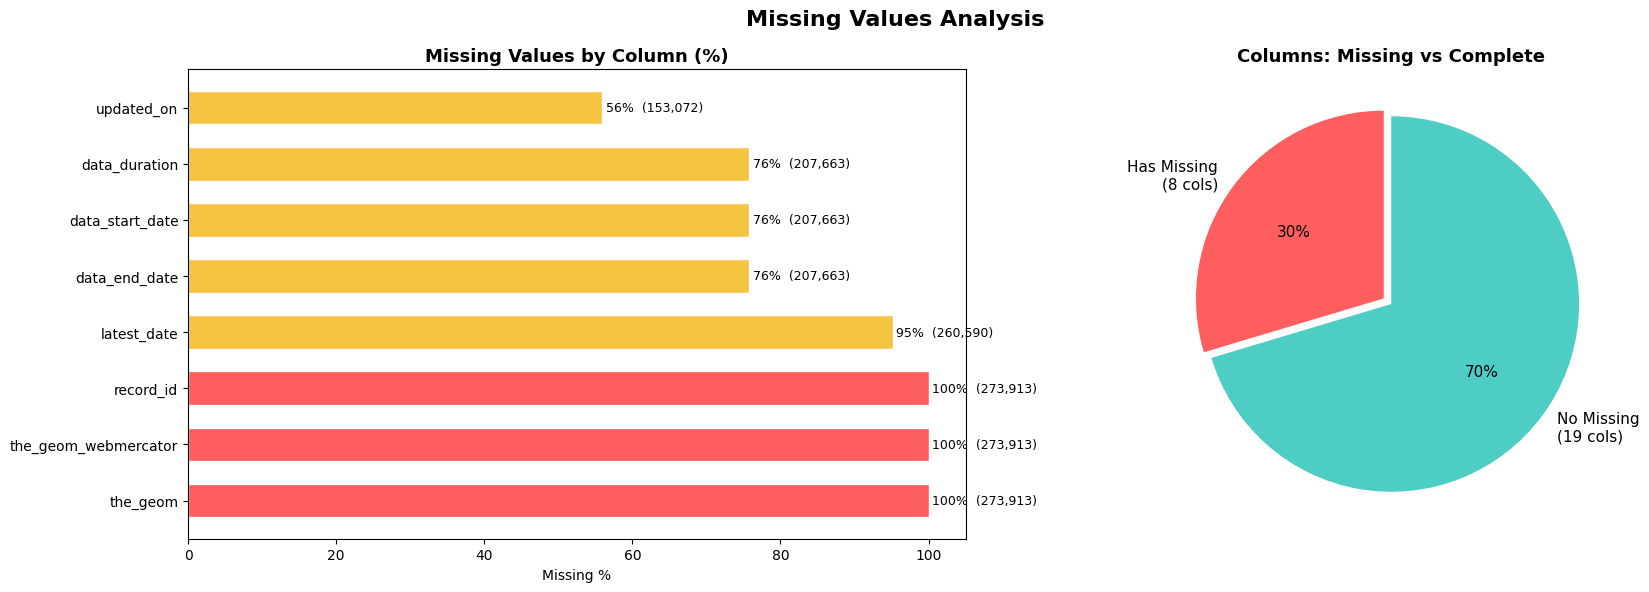

In [3]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %'    : missing_pct
}).sort_values('Missing %', ascending=False)

has_missing = missing_df[missing_df['Missing %'] > 0]
no_missing  = missing_df[missing_df['Missing %'] == 0]

print(f'Columns WITH missing  : {len(has_missing)}')
print(f'Columns with NO missing: {len(no_missing)}')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Missing Values Analysis', fontsize=16, fontweight='bold')

colors = ['#ff5e5e' if x == 100 else '#f5c542' if x > 50 else '#4ecdc4'
          for x in has_missing['Missing %']]

bars = axes[0].barh(has_missing.index, has_missing['Missing %'],
                    color=colors, edgecolor='white', height=0.6)
axes[0].set_title('Missing Values by Column (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Missing %')
for bar, val, cnt in zip(bars, has_missing['Missing %'], has_missing['Missing Count']):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{val:.0f}%  ({cnt:,})', va='center', fontsize=9)

axes[1].pie(
    [len(has_missing), len(no_missing)],
    labels=[f'Has Missing\n({len(has_missing)} cols)', f'No Missing\n({len(no_missing)} cols)'],
    colors=['#ff5e5e', '#4ecdc4'], explode=(0.05, 0),
    autopct='%1.0f%%', startangle=90, textprops={'fontsize': 11}
)
axes[1].set_title('Columns: Missing vs Complete', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Drop Useless Columns
- **100% empty:** `the_geom`, `the_geom_webmercator`, `record_id`
- **Mostly empty:** `latest_date`, `data_start_date`, `data_end_date`, `data_duration`, `updated_on`
- **Single value — zero info:** `count_type`, `publish`, `data_quality_indicator`
- **ID / hash — not predictive:** `cartodb_id`, `md5`

In [4]:
cols_to_drop = [
    'the_geom', 'the_geom_webmercator', 'record_id',
    'latest_date', 'data_start_date', 'data_end_date',
    'data_duration', 'updated_on', 'md5', 'cartodb_id',
    'count_type', 'publish', 'data_quality_indicator'
]
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)
print(f'Shape after dropping: {df.shape}')

Shape after dropping: (273913, 14)


## 4. Explore Remaining Columns

In [5]:
df.describe(include='all')

,station_key,station_id,traffic_direction_seq,traffic_direction_name,cardinal_direction_seq,cardinal_direction_name,classification_seq,classification_type,year,period,partial_year,traffic_count,data_availability,data_reliability
count,2.739130e+05,273913,273913.000000,273913,273913.000000,273913,273913.000000,273913,273913.000000,273913,273913,273913.000000,273913.000000,273913.000000
unique,NaN,1967,NaN,3,NaN,7,NaN,4,NaN,8,2,NaN,NaN,NaN
top,NaN,50260,NaN,PRESCRIBED,NaN,SOUTH,NaN,UNCLASSIFIED,NaN,ALL DAYS,False,NaN,NaN,NaN
freq,NaN,1137,NaN,97612,NaN,58537,NaN,76357,NaN,42266,260590,NaN,NaN,NaN
mean,1.063049e+07,NaN,0.945256,NaN,5.446112,NaN,1.444769,NaN,2015.186585,NaN,NaN,7699.555326,14.227477,31.303951
std,2.173051e+07,NaN,0.800402,NaN,3.175565,NaN,1.134309,NaN,6.078075,NaN,NaN,12794.508826,28.758026,43.974719
min,-1.000000e+00,NaN,0.000000,NaN,1.000000,NaN,0.000000,NaN,2006.000000,NaN,NaN,1.000000,-1.000000,-1.000000
25%,5.698200e+04,NaN,0.000000,NaN,3.000000,NaN,0.000000,NaN,2010.000000,NaN,NaN,444.000000,-1.000000,-1.000000
50%,5.825700e+04,NaN,1.000000,NaN,5.000000,NaN,1.000000,NaN,2015.000000,NaN,NaN,2100.000000,-1.000000,-1.000000
75%,1.528600e+07,NaN,2.000000,NaN,9.000000,NaN,2.000000,NaN,2020.000000,NaN,NaN,9616.000000,12.000000,88.000000


In [6]:
for col in df.select_dtypes(include=np.number).columns:
    print(f'\n{col}')
    print(f'  Min   : {df[col].min()}')
    print(f'  Max   : {df[col].max()}')
    print(f'  Mean  : {df[col].mean():.2f}')
    print(f'  Nulls : {df[col].isnull().sum()}')
    if df[col].nunique() <= 10:
        print(f'  Unique: {sorted(df[col].dropna().unique())}')


station_key
  Min   : -1
  Max   : 99990015
  Mean  : 10630487.62
  Nulls : 0

traffic_direction_seq
  Min   : 0
  Max   : 2
  Mean  : 0.95
  Nulls : 0
  Unique: [np.int64(0), np.int64(1), np.int64(2)]

cardinal_direction_seq
  Min   : 1
  Max   : 10
  Mean  : 5.45
  Nulls : 0
  Unique: [np.int64(1), np.int64(3), np.int64(5), np.int64(7), np.int64(9), np.int64(10)]

classification_seq
  Min   : 0
  Max   : 3
  Mean  : 1.44
  Nulls : 0
  Unique: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

year
  Min   : 2006
  Max   : 2026
  Mean  : 2015.19
  Nulls : 0

traffic_count
  Min   : 1
  Max   : 183074
  Mean  : 7699.56
  Nulls : 0

data_availability
  Min   : -1
  Max   : 100
  Mean  : 14.23
  Nulls : 0

data_reliability
  Min   : -1
  Max   : 100
  Mean  : 31.30
  Nulls : 0


In [7]:
for col in df.select_dtypes(include='object').columns:
    print(f'\n{col}  ({df[col].nunique()} unique)')
    print(df[col].value_counts())


station_id  (1967 unique)
station_id
50260       1137
29005       1134
74228       1134
72027       1133
F3FWY001    1115
            ... 
02376          6
85026          6
92503          6
83013          5
07297          2
Name: count, Length: 1967, dtype: int64

traffic_direction_name  (3 unique)
traffic_direction_name
PRESCRIBED                97612
COUNTER                   95648
PRESCRIBED AND COUNTER    80653
Name: count, dtype: int64

cardinal_direction_name  (7 unique)
cardinal_direction_name
SOUTH                        58537
NORTH                        58379
WEST                         38480
EAST                         37864
NORTHBOUND AND SOUTHBOUND    32173
BOTH                         28072
EASTBOUND AND WESTBOUND      20408
Name: count, dtype: int64

classification_type  (4 unique)
classification_type
UNCLASSIFIED      76357
LIGHT VEHICLES    66111
HEAVY VEHICLES    66037
ALL VEHICLES      65408
Name: count, dtype: int64

period  (8 unique)
period
ALL DAYS           4

## 5. Clean Data

In [8]:
# -1 is a sentinel for "no data" in these two columns — replace with median
df['data_availability'].replace(-1, np.nan, inplace=True)
df['data_reliability'].replace(-1, np.nan,  inplace=True)
df['data_availability'].fillna(df['data_availability'].median(), inplace=True)
df['data_reliability'].fillna(df['data_reliability'].median(),   inplace=True)

# Year 2026 appears in the data but is a future/error entry
df.drop(df[df['year'] == 2026].index, inplace=True)

# SCHOOL HOLIDAYS has very few rows — not worth encoding
df.drop(df[df['period'] == 'SCHOOL HOLIDAYS'].index, inplace=True)

print('Year range :', sorted(df['year'].unique()))
print('Periods    :', sorted(df['period'].unique()))

Year range : [np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Periods    : ['ALL DAYS', 'AM PEAK', 'OFF PEAK', 'PM PEAK', 'PUBLIC HOLIDAYS', 'WEEKDAYS', 'WEEKENDS']


In [9]:
# Sequence columns are just integer versions of the name columns — redundant
drop2 = [c for c in [
    'station_key', 'traffic_direction_seq', 'cardinal_direction_seq',
    'classification_seq', 'partial_year', 'data_availability', 'data_reliability'
] if c in df.columns]

df.drop(columns=drop2, inplace=True)
print(f'Final clean shape: {df.shape}')
df.head()

Final clean shape: (265291, 7)


,station_id,traffic_direction_name,cardinal_direction_name,classification_type,year,period,traffic_count
0,02015,PRESCRIBED AND COUNTER,BOTH,UNCLASSIFIED,2018,WEEKDAYS,39273
1,6157,COUNTER,SOUTH,HEAVY VEHICLES,2022,ALL DAYS,705
2,83011,COUNTER,SOUTH,HEAVY VEHICLES,2020,ALL DAYS,1722
3,F3FWY006,PRESCRIBED AND COUNTER,BOTH,HEAVY VEHICLES,2018,PM PEAK,2178
4,34029,COUNTER,SOUTH,UNCLASSIFIED,2016,WEEKDAYS,7541


## 6. EDA

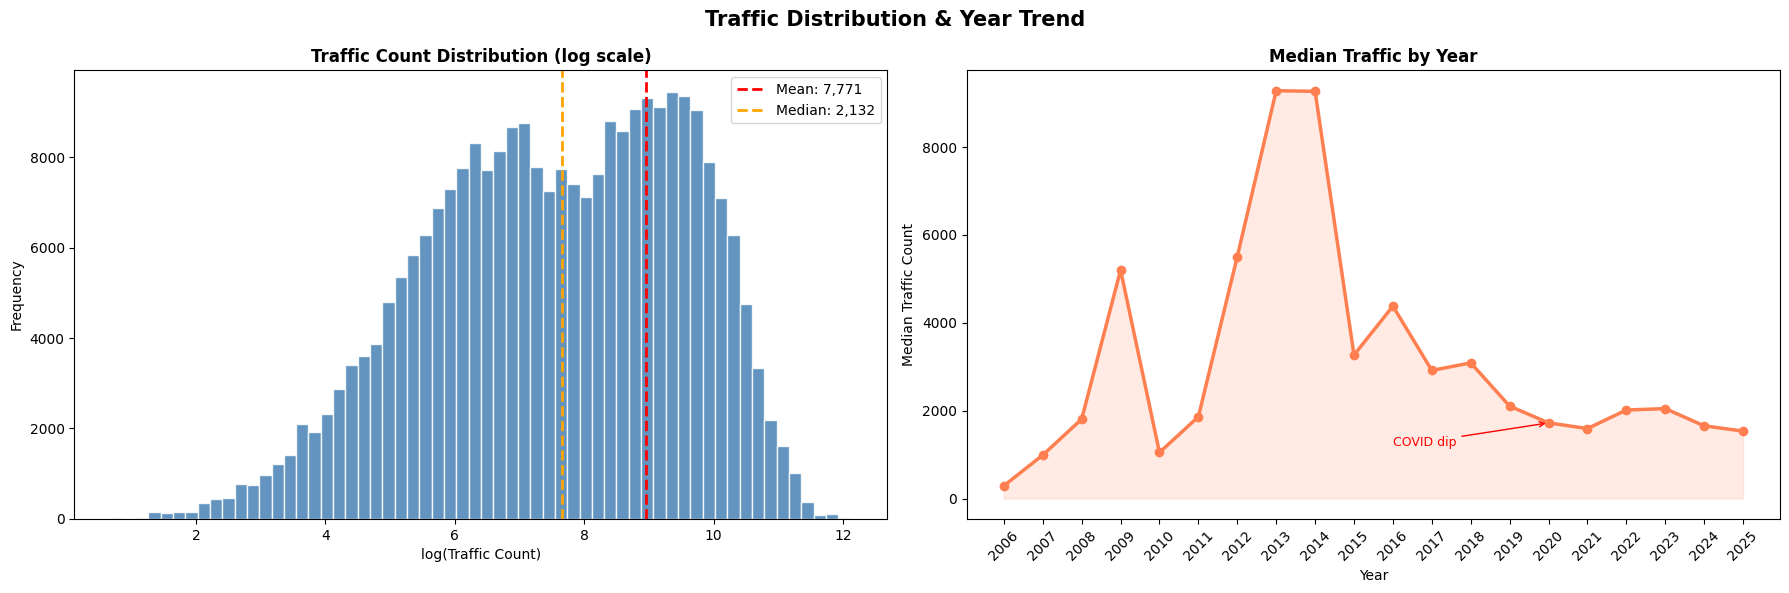

Min    : 1
Max    : 183,074
Mean   : 7,771
Median : 2,132
Mean >> Median  =>  right skewed  =>  use log transform before ML


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Traffic Distribution & Year Trend', fontsize=15, fontweight='bold')

axes[0].hist(np.log1p(df['traffic_count']), bins=60,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Traffic Count Distribution (log scale)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('log(Traffic Count)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.log1p(df['traffic_count'].mean()),
                color='red', linestyle='--', linewidth=2,
                label=f'Mean: {df["traffic_count"].mean():,.0f}')
axes[0].axvline(np.log1p(df['traffic_count'].median()),
                color='orange', linestyle='--', linewidth=2,
                label=f'Median: {df["traffic_count"].median():,.0f}')
axes[0].legend()

year_avg = df.groupby('year')['traffic_count'].median()
axes[1].plot(year_avg.index, year_avg.values, color='coral',
             linewidth=2.5, marker='o', markersize=6)
axes[1].fill_between(year_avg.index, year_avg.values, alpha=0.15, color='coral')

if 2020 in year_avg.index:
    axes[1].annotate('COVID dip',
                     xy=(2020, year_avg[2020]),
                     xytext=(2016, year_avg[2020] * 0.7),
                     arrowprops=dict(arrowstyle='->', color='red'),
                     fontsize=9, color='red')

axes[1].set_title('Median Traffic by Year', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Median Traffic Count')
axes[1].set_xticks(year_avg.index)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f'Min    : {df["traffic_count"].min():,}')
print(f'Max    : {df["traffic_count"].max():,}')
print(f'Mean   : {df["traffic_count"].mean():,.0f}')
print(f'Median : {df["traffic_count"].median():,.0f}')
print('Mean >> Median  =>  right skewed  =>  use log transform before ML')

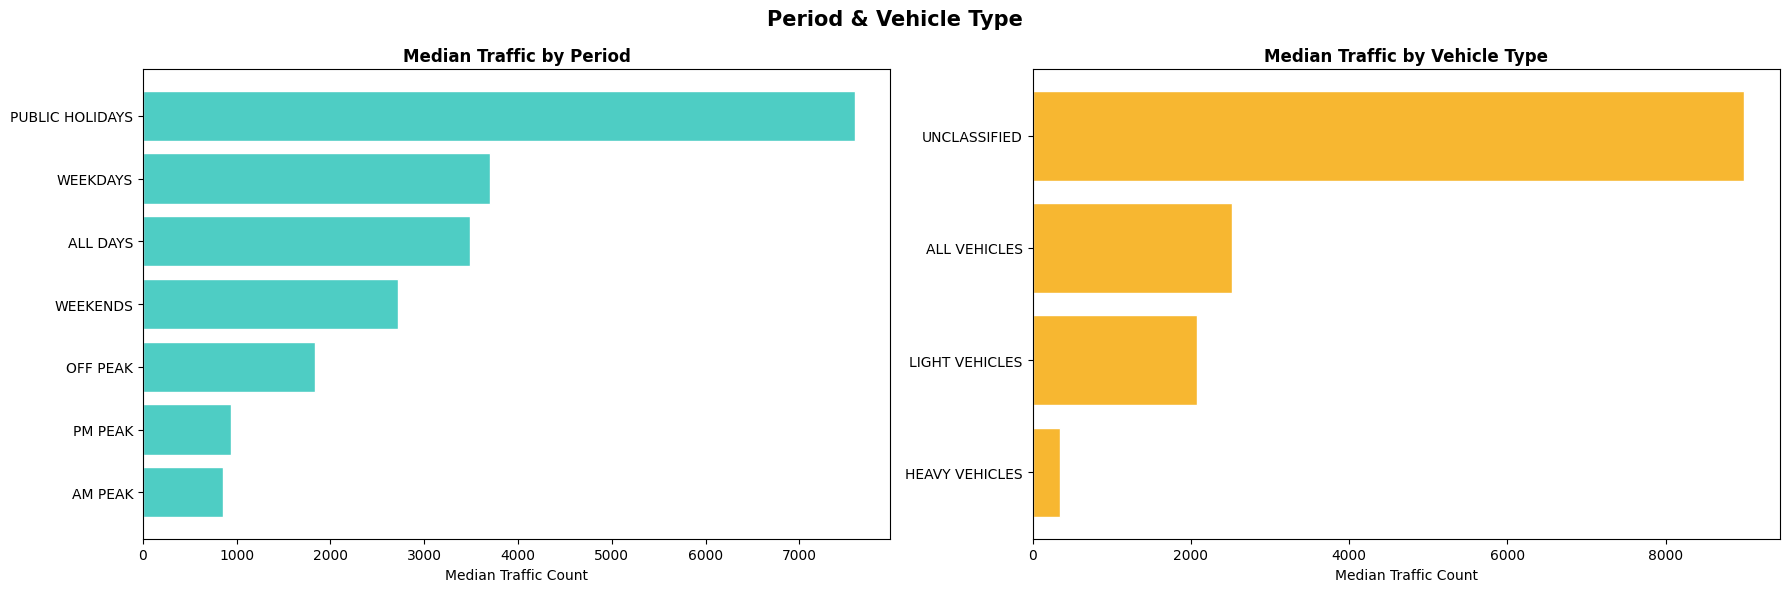

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Period & Vehicle Type', fontsize=15, fontweight='bold')

period_avg = df.groupby('period')['traffic_count'].median().sort_values()
axes[0].barh(period_avg.index, period_avg.values, color='#4ecdc4', edgecolor='white')
axes[0].set_title('Median Traffic by Period', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Median Traffic Count')

class_avg = df.groupby('classification_type')['traffic_count'].median().sort_values()
axes[1].barh(class_avg.index, class_avg.values, color='#f7b731', edgecolor='white')
axes[1].set_title('Median Traffic by Vehicle Type', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Median Traffic Count')

plt.tight_layout()
plt.show()

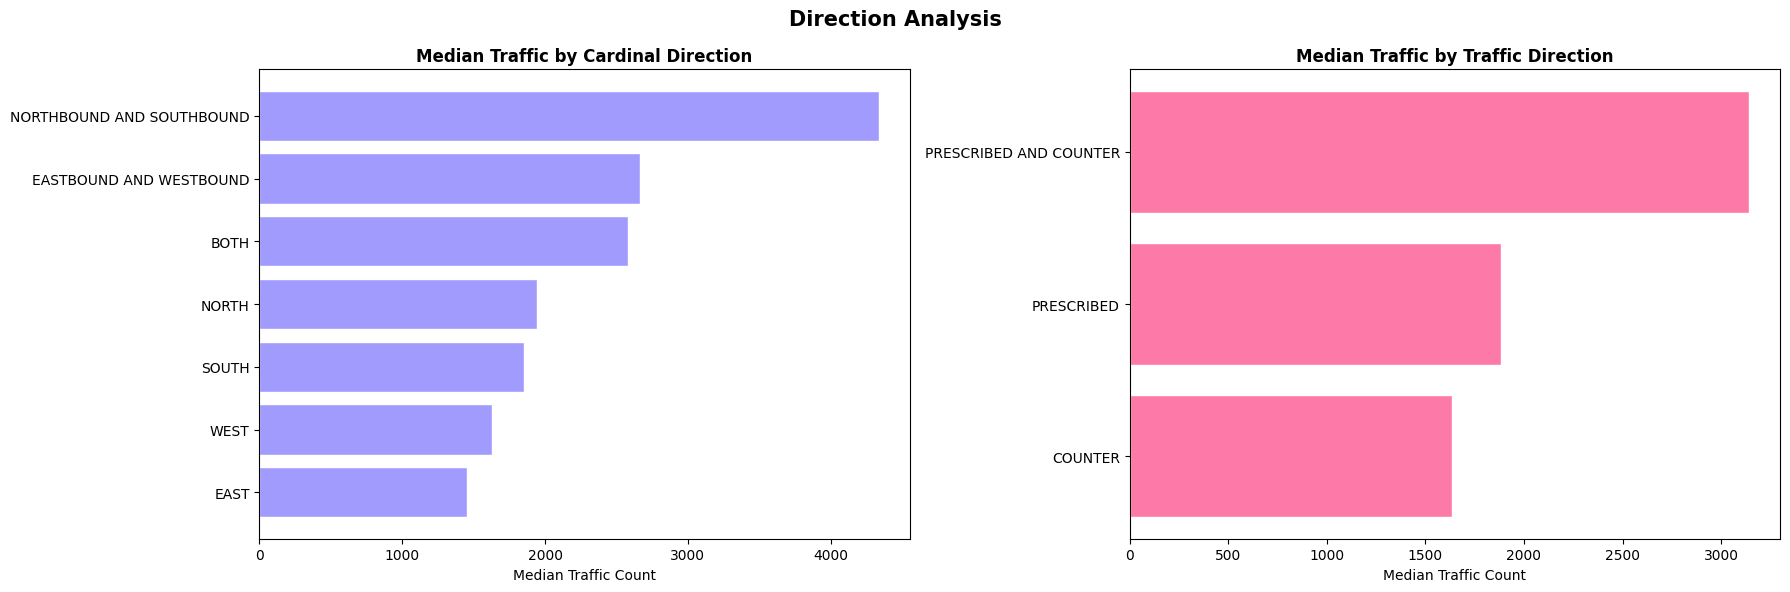

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Direction Analysis', fontsize=15, fontweight='bold')

card_avg = df.groupby('cardinal_direction_name')['traffic_count'].median().sort_values()
axes[0].barh(card_avg.index, card_avg.values, color='#a29bfe', edgecolor='white')
axes[0].set_title('Median Traffic by Cardinal Direction', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Median Traffic Count')

traf_avg = df.groupby('traffic_direction_name')['traffic_count'].median().sort_values()
axes[1].barh(traf_avg.index, traf_avg.values, color='#fd79a8', edgecolor='white')
axes[1].set_title('Median Traffic by Traffic Direction', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Median Traffic Count')

plt.tight_layout()
plt.show()

## 7. Feature Engineering

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['station_id_enc']              = le.fit_transform(df['station_id'].astype(str))
df['traffic_direction_name_enc']  = le.fit_transform(df['traffic_direction_name'].astype(str))
df['cardinal_direction_name_enc'] = le.fit_transform(df['cardinal_direction_name'].astype(str))
df['classification_type_enc']     = le.fit_transform(df['classification_type'].astype(str))
df['period_enc']                  = le.fit_transform(df['period'].astype(str))

# Binary flags help tree models find patterns faster
df['is_peak']            = df['period'].str.contains('PEAK',    na=False).astype(int)
df['is_weekend']         = df['period'].str.contains('WEEKEND', na=False).astype(int)
df['is_holiday']         = df['period'].str.contains('HOLIDAY', na=False).astype(int)
df['is_both_directions'] = df['traffic_direction_name'].str.contains('AND', na=False).astype(int)
df['is_heavy']           = (df['classification_type'] == 'HEAVY VEHICLES').astype(int)
df['decade']             = (df['year'] // 10) * 10

# Station average: captures how busy each station typically is
station_avg_map = df.groupby('station_id_enc')['traffic_count'].mean().to_dict()
global_mean     = df['traffic_count'].mean()
df['station_avg'] = df['station_id_enc'].map(station_avg_map)

print('Features created')
df.head(3)

Features created


,station_id,traffic_direction_name,cardinal_direction_name,classification_type,year,period,traffic_count,station_id_enc,traffic_direction_name_enc,cardinal_direction_name_enc,classification_type_enc,period_enc,is_peak,is_weekend,is_holiday,is_both_directions,is_heavy,decade,station_avg
0,02015,PRESCRIBED AND COUNTER,BOTH,UNCLASSIFIED,2018,WEEKDAYS,39273,7,2,0,3,5,0,0,0,1,0,2010,17321.637037
1,6157,COUNTER,SOUTH,HEAVY VEHICLES,2022,ALL DAYS,705,869,0,5,1,0,0,0,0,0,1,2020,2903.824324
2,83011,COUNTER,SOUTH,HEAVY VEHICLES,2020,ALL DAYS,1722,1061,0,5,1,0,0,0,0,0,1,2020,12464.427284


## 8. Train / Test Split (time-based)
Splitting by year is more realistic than random split —  
train on 2006–2021, test on 2022–2025.

In [14]:
FEATURES = [
    'station_id_enc',
    'traffic_direction_name_enc',
    'cardinal_direction_name_enc',
    'classification_type_enc',
    'period_enc',
    'station_avg',
    'year',
    'is_peak',
    'is_weekend',
    'is_holiday',
    'is_both_directions',
    'is_heavy',
    'decade'
]

split_year = 2021
train_df = df[df['year'] <= split_year]
test_df  = df[df['year'] >  split_year]

x_train = train_df[FEATURES]
y_train = np.log1p(train_df['traffic_count'])
x_test  = test_df[FEATURES]
y_test  = np.log1p(test_df['traffic_count'])

print(f'Train : {x_train.shape}  ({train_df["year"].min()} - {train_df["year"].max()})')
print(f'Test  : {x_test.shape}   ({test_df["year"].min()} - {test_df["year"].max()})')

Train : (221450, 13)  (2006 - 2021)
Test  : (43841, 13)   (2022 - 2025)


## 9. Train & Compare Models

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

pipelines = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=1.0))
    ]),
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Lasso(alpha=1.0))
    ]),
    'Decision Tree': Pipeline([
        ('model', DecisionTreeRegressor(
            max_depth=15, min_samples_leaf=5, random_state=42
        ))
    ]),
    'Random Forest': Pipeline([
        ('model', RandomForestRegressor(
            n_estimators=100, max_depth=12, min_samples_leaf=5,
            max_features='sqrt', random_state=42, n_jobs=-1
        ))
    ]),
    'Extra Trees': Pipeline([
        ('model', ExtraTreesRegressor(
            n_estimators=80, max_depth=15, min_samples_leaf=5,
            max_features='sqrt', random_state=42, n_jobs=-1
        ))
    ]),
    'XGBoost': Pipeline([
        ('model', XGBRegressor(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, n_jobs=-1, verbosity=0
        ))
    ])
}

In [16]:
results = {}

for name, pipe in pipelines.items():
    print(f'Training {name}...', end=' ', flush=True)
    pipe.fit(x_train, y_train)

    preds      = pipe.predict(x_test)
    preds_raw  = np.expm1(preds)
    y_test_raw = np.expm1(y_test)

    r2   = r2_score(y_test, preds)
    mae  = mean_absolute_error(y_test_raw, preds_raw)
    rmse = np.sqrt(mean_squared_error(y_test_raw, preds_raw))

    results[name] = {'R2': r2, 'MAE': mae, 'RMSE': rmse, 'PIPELINE': pipe}
    print(f'R2={r2:.4f}  MAE={mae:>8,.0f}  RMSE={rmse:>10,.0f}')

Training Linear Regression... R2=0.6180  MAE=   7,963  RMSE=   152,345
Training Ridge... R2=0.6180  MAE=   7,963  RMSE=   152,340
Training Lasso... R2=0.1697  MAE=   5,027  RMSE=    10,720
Training Decision Tree... R2=0.8868  MAE=   1,161  RMSE=     2,717
Training Random Forest... R2=0.8905  MAE=   1,562  RMSE=     3,730
Training Extra Trees... R2=0.8214  MAE=   2,346  RMSE=     5,017
Training XGBoost... R2=0.9229  MAE=   1,173  RMSE=     2,691


## 10. Results & Best Model

In [17]:
results_df = pd.DataFrame([
    {'Model': k, 'R2': v['R2'], 'MAE': v['MAE'], 'RMSE': v['RMSE']}
    for k, v in results.items()
]).sort_values('R2', ascending=False).reset_index(drop=True)

print(results_df.to_string(index=False))

best = max(results, key=lambda m: results[m]['R2'])
print(f'\nBest model : {best}')
print(f'  R2   : {results[best]["R2"]:.4f}')
print(f'  MAE  : {results[best]["MAE"]:,.0f}')
print(f'  RMSE : {results[best]["RMSE"]:,.0f}')

            Model       R2         MAE          RMSE
          XGBoost 0.922878 1173.352675   2690.895246
    Random Forest 0.890488 1561.866822   3730.058341
    Decision Tree 0.886834 1160.616262   2717.107125
      Extra Trees 0.821351 2345.655961   5017.326158
            Ridge 0.617968 7962.904494 152339.661730
Linear Regression 0.617967 7963.091686 152344.659305
            Lasso 0.169650 5026.723916  10719.562088

Best model : XGBoost
  R2   : 0.9229
  MAE  : 1,173
  RMSE : 2,691


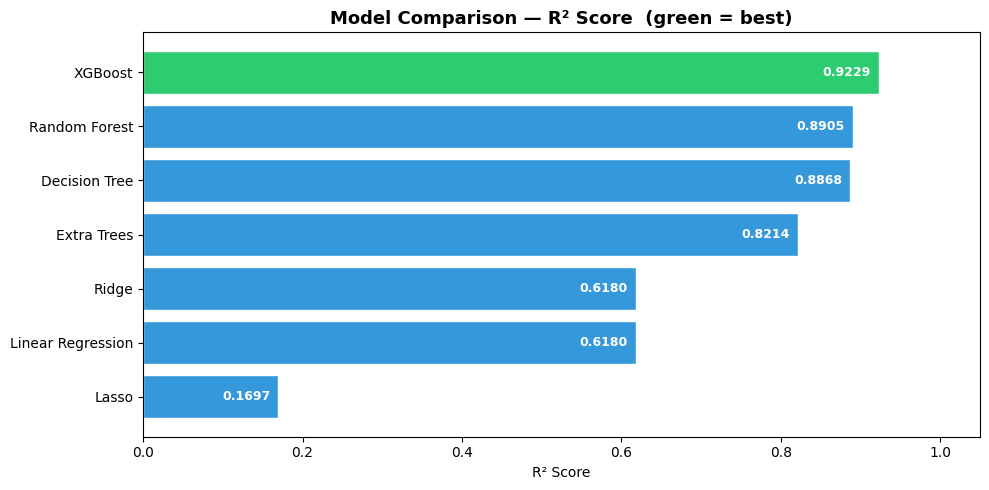

In [18]:
r2_series = pd.Series({k: v['R2'] for k, v in results.items()}).sort_values()
colors    = ['#2ecc71' if k == best else '#3498db' for k in r2_series.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(r2_series.index, r2_series.values, color=colors, edgecolor='white')
for bar, val in zip(bars, r2_series.values):
    ax.text(val - 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', ha='right',
            fontsize=9, color='white', fontweight='bold')

ax.set_title('Model Comparison — R² Score  (green = best)', fontsize=13, fontweight='bold')
ax.set_xlabel('R² Score')
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()

## 11. Actual vs Predicted

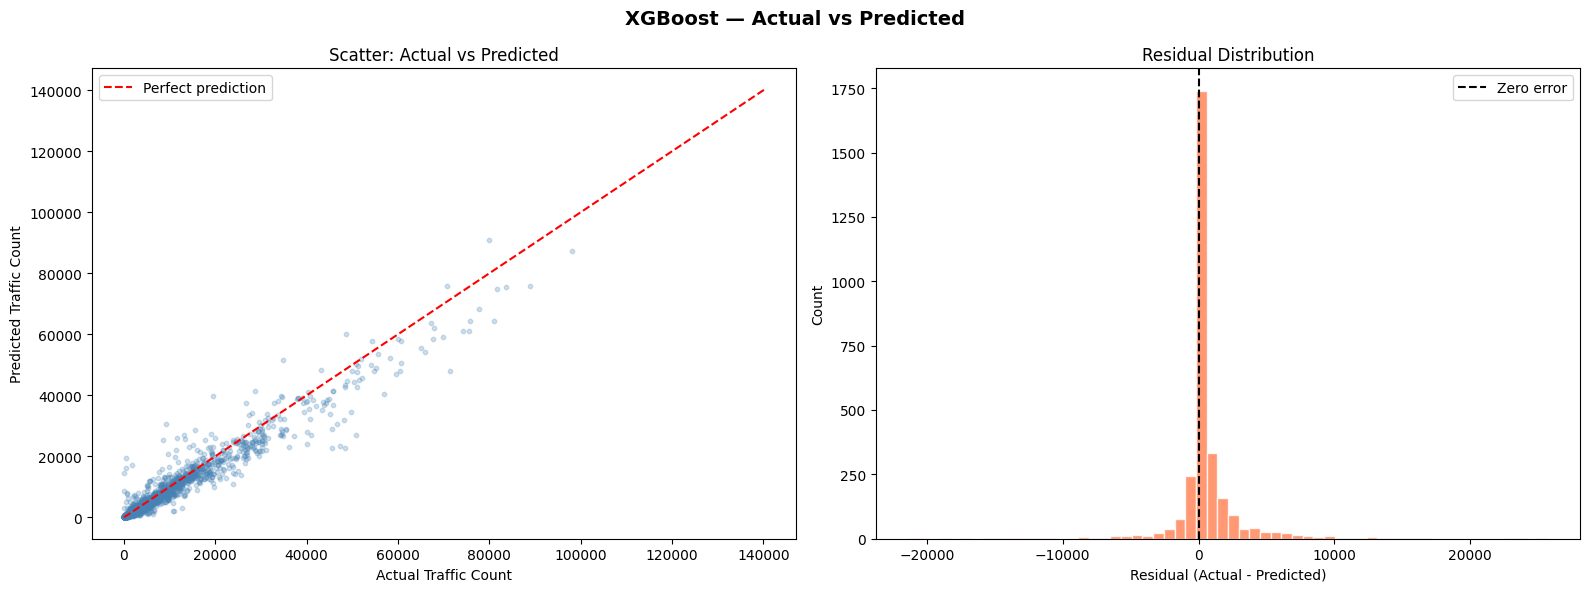

Within 10% error : 28.1% of test rows
Within 20% error : 53.7% of test rows
Within 30% error : 71.5% of test rows


In [19]:
best_pipe  = results[best]['PIPELINE']
preds_log  = best_pipe.predict(x_test)
preds_raw  = np.expm1(preds_log)
actual_raw = np.expm1(y_test)

idx = np.random.choice(len(actual_raw), size=min(3000, len(actual_raw)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'{best} — Actual vs Predicted', fontsize=14, fontweight='bold')

axes[0].scatter(actual_raw.iloc[idx], preds_raw[idx],
                alpha=0.25, s=10, color='steelblue')
max_val = max(actual_raw.max(), preds_raw.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Traffic Count')
axes[0].set_ylabel('Predicted Traffic Count')
axes[0].set_title('Scatter: Actual vs Predicted')
axes[0].legend()

residuals = actual_raw.values - preds_raw
axes[1].hist(residuals[idx], bins=60, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--', label='Zero error')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

pct_error = np.abs(actual_raw.values - preds_raw) / actual_raw.values * 100
print(f'Within 10% error : {(pct_error <= 10).mean() * 100:.1f}% of test rows')
print(f'Within 20% error : {(pct_error <= 20).mean() * 100:.1f}% of test rows')
print(f'Within 30% error : {(pct_error <= 30).mean() * 100:.1f}% of test rows')

## 12. Feature Importance

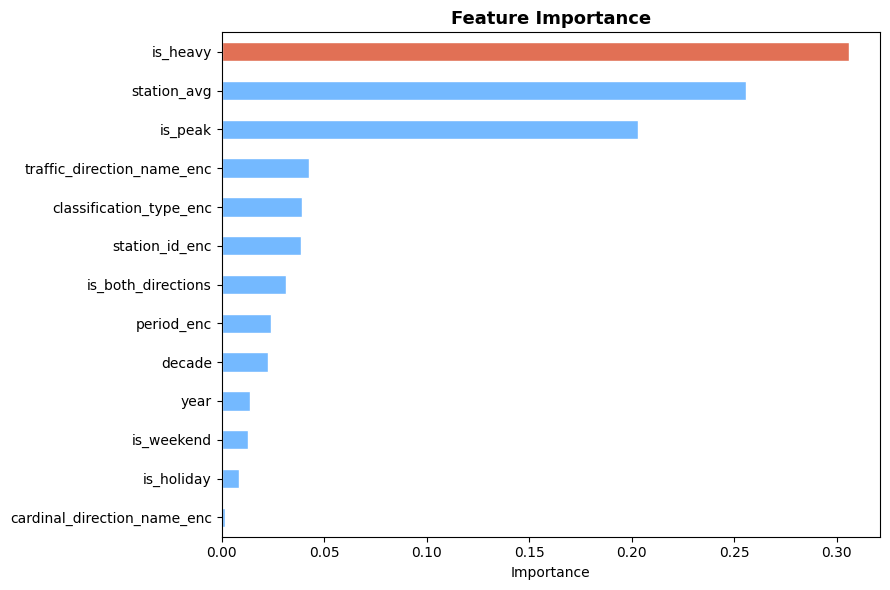

Top 3 most important features:
  is_heavy                            0.3058
  station_avg                         0.2559
  is_peak                             0.2028


In [20]:
best_model = results[best]['PIPELINE'].named_steps['model']

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(
        best_model.feature_importances_, index=FEATURES
    ).sort_values()

    colors = ['#e17055' if f == importances.idxmax() else '#74b9ff'
              for f in importances.index]

    fig, ax = plt.subplots(figsize=(9, 6))
    importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.set_title('Feature Importance', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

    print('Top 3 most important features:')
    for f, v in importances.sort_values(ascending=False).head(3).items():
        print(f'  {f:<35} {v:.4f}')
else:
    print(f'{best} does not have feature_importances_')

## 13. Predict Function

In [21]:
# These match the label encoding from training
period_map = {
    'ALL DAYS': 0, 'AM PEAK': 1, 'OFF PEAK': 2,
    'PM PEAK': 3, 'PUBLIC HOLIDAYS': 4, 'WEEKDAYS': 5, 'WEEKENDS': 6
}
class_map = {
    'ALL VEHICLES': 0, 'HEAVY VEHICLES': 1,
    'LIGHT VEHICLES': 2, 'UNCLASSIFIED': 3
}
direction_map = {
    'BOTH': 0, 'EAST': 1, 'EASTBOUND AND WESTBOUND': 2,
    'NORTH': 3, 'NORTHBOUND AND SOUTHBOUND': 4, 'SOUTH': 5, 'WEST': 6
}
traffic_dir_map = {
    'COUNTER': 0, 'PRESCRIBED': 1, 'PRESCRIBED AND COUNTER': 2
}


def predict_traffic(station_id_enc, year, period,
                    classification_type, cardinal_direction, traffic_direction):
    """
    Predict traffic count for given conditions.

    station_id_enc      : int  — from df['station_id_enc']
    year                : int  — e.g. 2024
    period              : str  — e.g. 'WEEKDAYS', 'AM PEAK'
    classification_type : str  — e.g. 'UNCLASSIFIED', 'HEAVY VEHICLES'
    cardinal_direction  : str  — e.g. 'NORTH', 'SOUTH'
    traffic_direction   : str  — e.g. 'PRESCRIBED', 'COUNTER'
    """
    is_peak            = 1 if 'PEAK'    in period.upper() else 0
    is_weekend         = 1 if 'WEEKEND' in period.upper() else 0
    is_holiday         = 1 if 'HOLIDAY' in period.upper() else 0
    is_both_directions = 1 if 'AND'     in traffic_direction.upper() else 0
    is_heavy           = 1 if classification_type.upper() == 'HEAVY VEHICLES' else 0
    decade             = (year // 10) * 10
    station_avg_value  = station_avg_map.get(station_id_enc, global_mean)

    row = pd.DataFrame([{
        'station_id_enc'              : station_id_enc,
        'traffic_direction_name_enc'  : traffic_dir_map.get(traffic_direction.upper(), 1),
        'cardinal_direction_name_enc' : direction_map.get(cardinal_direction.upper(), 3),
        'classification_type_enc'     : class_map.get(classification_type.upper(), 0),
        'period_enc'                  : period_map.get(period.upper(), 5),
        'station_avg'                 : station_avg_value,
        'year'                        : year,
        'is_peak'                     : is_peak,
        'is_weekend'                  : is_weekend,
        'is_holiday'                  : is_holiday,
        'is_both_directions'          : is_both_directions,
        'is_heavy'                    : is_heavy,
        'decade'                      : decade
    }])[FEATURES]

    return int(np.expm1(results[best]['PIPELINE'].predict(row)[0]))


print('predict_traffic() ready')

predict_traffic() ready


In [22]:
# Predictions across all periods for station 1
print(f"{'Period':<20} {'Predicted':>12}")
print('-' * 34)
for period in ['ALL DAYS', 'AM PEAK', 'PM PEAK', 'OFF PEAK',
               'WEEKDAYS', 'WEEKENDS', 'PUBLIC HOLIDAYS']:
    pred = predict_traffic(
        station_id_enc=1, year=2023, period=period,
        classification_type='UNCLASSIFIED',
        cardinal_direction='NORTH',
        traffic_direction='PRESCRIBED'
    )
    print(f'{period:<20} {pred:>12,}')

Period                  Predicted
----------------------------------
ALL DAYS                   47,301
AM PEAK                    12,263
PM PEAK                    13,646
OFF PEAK                   22,660
WEEKDAYS                   49,570
WEEKENDS                   43,080
PUBLIC HOLIDAYS            32,230


In [23]:
# Year trend
print(f"{'Year':<8} {'Predicted':>12}  Note")
print('-' * 36)
for yr in [2010, 2013, 2016, 2018, 2020, 2022, 2024, 2025]:
    pred = predict_traffic(
        station_id_enc=1, year=yr, period='ALL DAYS',
        classification_type='UNCLASSIFIED',
        cardinal_direction='NORTH',
        traffic_direction='PRESCRIBED'
    )
    note = '<- COVID year' if yr == 2020 else ''
    print(f'{yr:<8} {pred:>12,}  {note}')

Year        Predicted  Note
------------------------------------
2010           55,237  
2013           56,106  
2016           56,076  
2018           59,221  
2020           49,170  <- COVID year
2022           47,301  
2024           47,301  
2025           47,301  


In [24]:
# Sanity check: predict on real test rows and compare
sample       = test_df.sample(15, random_state=42)
sample_preds = np.expm1(results[best]['PIPELINE'].predict(sample[FEATURES]))

print(f"{'Actual':>10} {'Predicted':>10} {'Error %':>8}  Status")
print('-' * 45)
for actual, pred in zip(sample['traffic_count'].values, sample_preds):
    err    = abs(actual - pred) / actual * 100
    status = 'GOOD'  if err < 10 else 'OK' if err < 20 else 'CHECK'
    print(f'{actual:>10,} {int(pred):>10,} {err:>7.1f}%  {status}')

    Actual  Predicted  Error %  Status
---------------------------------------------
     1,081        574    46.9%  CHECK
    21,968     15,842    27.9%  CHECK
       425        306    27.8%  CHECK
     1,381      1,245     9.8%  GOOD
     1,168        957    18.0%  OK
     3,361      3,636     8.2%  GOOD
    33,339     24,363    26.9%  CHECK
    37,838     27,820    26.5%  CHECK
       243        220     9.4%  GOOD
       267        271     1.6%  GOOD
       957        895     6.4%  GOOD
    29,569     23,211    21.5%  CHECK
     2,517      4,914    95.3%  CHECK
    13,577     16,815    23.9%  CHECK
     4,304      3,465    19.5%  OK


## 14. Save Model

In [25]:
import joblib, os

os.makedirs('models', exist_ok=True)

joblib.dump(results[best]['PIPELINE'], 'models/best_model.pkl')
joblib.dump(FEATURES,                  'models/features.pkl')
joblib.dump({
    'period_map'     : period_map,
    'class_map'      : class_map,
    'direction_map'  : direction_map,
    'traffic_dir_map': traffic_dir_map
}, 'models/encodings.pkl')

station_lookup = (
    df.groupby(['station_id', 'station_id_enc'])['traffic_count']
    .median().reset_index()
    .sort_values('traffic_count', ascending=False)
)
joblib.dump(station_lookup, 'models/station_lookup.pkl')

print('Models saved!')
for f in sorted(os.listdir('models')):
    size_mb = os.path.getsize(f'models/{f}') / 1_048_576
    print(f'  models/{f:<30} {size_mb:.1f} MB')

print(f'\nBest model : {best}')
print(f'R2         : {results[best]["R2"]:.4f}')
print(f'MAE        : {results[best]["MAE"]:,.0f}')
print(f'RMSE       : {results[best]["RMSE"]:,.0f}')
print(f'Train rows : {x_train.shape[0]:,}')
print(f'Test rows  : {x_test.shape[0]:,}')
print(f'Stations   : {df["station_id"].nunique():,}')
print(f'Years      : {df["year"].min()} - {df["year"].max()}')

Models saved!
  models/best_model.pkl                 1.4 MB
  models/encodings.pkl                  0.0 MB
  models/features.pkl                   0.0 MB
  models/station_lookup.pkl             0.1 MB

Best model : XGBoost
R2         : 0.9229
MAE        : 1,173
RMSE       : 2,691
Train rows : 221,450
Test rows  : 43,841
Stations   : 1,967
Years      : 2006 - 2025
